In [2]:
# ============================================================
# 🎫 SUPPORT TICKET CLASSIFICATION & PRIORITIZATION SYSTEM
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
import string
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder
import joblib

print("✅ Saari libraries load ho gayi!")
print("🚀 Project shuru karte hain...")

✅ Saari libraries load ho gayi!
🚀 Project shuru karte hain...


In [3]:
# ============================================================
# PART 2 - DATASET
# ============================================================

np.random.seed(42)

templates = {
    "Billing": [
        "I was charged twice for my subscription this month",
        "My invoice shows wrong amount please fix it urgently",
        "I need a refund for the unauthorized charge on my account",
        "Payment failed but money was deducted from my account",
        "Where is my billing statement for last month I need it",
        "My credit card was charged without my authorization ASAP",
        "Can I get a discount on my annual subscription plan",
        "I cancelled my subscription but still got charged refund",
        "My promo code did not apply to my bill please check",
        "Invoice amount does not match what I agreed to pay",
    ],
    "Technical Issue": [
        "The application crashes every time I try to upload files",
        "I cannot login and my password reset email not working",
        "The dashboard is loading very slowly today not working",
        "Error 500 appears every time I try to submit the form",
        "My data is not syncing between my devices issue",
        "The mobile app keeps freezing on the home screen crash",
        "API integration is returning wrong response error codes",
        "I cannot export data the export button does not work",
        "Two factor authentication is not sending SMS not working",
        "Database connection timeout error showing in my logs",
    ],
    "Account": [
        "I want to change my email address on my account please",
        "How do I add a new team member to my workspace today",
        "I need to delete my account and remove all my data",
        "My account got locked after too many login attempts",
        "Please update my company name in my account profile",
        "I want to merge two of my accounts together into one",
        "How do I enable single sign on SSO for my team",
        "I cannot access my previous account transaction history",
        "How do I revoke access for a former team member account",
        "I forgot my username and I cannot recover my account",
    ],
    "General Query": [
        "What features are included in the premium subscription plan",
        "How long does it normally take to process a refund request",
        "Do you offer a free trial period for new users signup",
        "What are your customer support team working hours",
        "Can I use your service in multiple countries worldwide",
        "Is there a mobile application available for download",
        "How do I integrate your product with third party tools",
        "What is your data privacy and security policy details",
        "Are there video tutorials available for beginner users",
        "How many users can I add to my current subscription plan",
    ],
}

HIGH_KW = ["urgent","asap","crash","error","failed","not working",
           "cannot login","charged twice","unauthorized","500","freeze","timeout"]
MED_KW  = ["slow","wrong","update","change","issue","problem","delay","upgrade"]

def assign_priority(text):
    t = text.lower()
    if any(k in t for k in HIGH_KW): return "High"
    if any(k in t for k in MED_KW):  return "Medium"
    return "Low"

rows = []
suffixes = ["", " please help", " urgently", " ASAP", " need this fixed", ""]
for cat, texts in templates.items():
    for i in range(150):
        t = texts[i % len(texts)] + " " + suffixes[i % len(suffixes)]
        rows.append({"ticket_text": t.strip(), 
                     "category": cat, 
                     "priority": assign_priority(t)})

df = pd.DataFrame(rows).sample(frac=1, random_state=42).reset_index(drop=True)
df["ticket_id"] = [f"TKT-{1000+i}" for i in range(len(df))]

print("✅ Dataset ready!")
print(f"📊 Total tickets: {len(df)}")
print(f"\n📁 Categories:")
print(df['category'].value_counts())
print(f"\n🚦 Priority:")
print(df['priority'].value_counts())
df.head(10)

✅ Dataset ready!
📊 Total tickets: 600

📁 Categories:
category
Billing            150
Account            150
General Query      150
Technical Issue    150
Name: count, dtype: int64

🚦 Priority:
priority
High      330
Low       240
Medium     30
Name: count, dtype: int64


,ticket_text,category,priority,ticket_id
0,I was charged twice for my subscription this m...,Billing,High,TKT-1000
1,I forgot my username and I cannot recover my a...,Account,Low,TKT-1001
2,Is there a mobile application available for do...,General Query,Low,TKT-1002
3,I cancelled my subscription but still got char...,Billing,Low,TKT-1003
4,I cannot login and my password reset email not...,Technical Issue,High,TKT-1004
5,My data is not syncing between my devices issu...,Technical Issue,High,TKT-1005
6,I was charged twice for my subscription this m...,Billing,High,TKT-1006
7,How many users can I add to my current subscri...,General Query,Low,TKT-1007
8,My promo code did not apply to my bill please ...,Billing,Low,TKT-1008
9,I forgot my username and I cannot recover my a...,Account,Low,TKT-1009


In [4]:
# ============================================================
# PART 3 - TEXT CLEANING
# ============================================================

STOP_WORDS = set(ENGLISH_STOP_WORDS)

def clean_text(text):
    text = str(text).lower()                    # lowercase
    text = re.sub(r'http\S+|www\S+', '', text)  # URLs hatao
    text = re.sub(r'\d+', '', text)             # numbers hatao
    text = text.translate(str.maketrans('', '', string.punctuation))  # punctuation hatao
    tokens = [t for t in text.split() 
              if t not in STOP_WORDS and len(t) > 2]  # stopwords hatao
    return ' '.join(tokens)

# Apply cleaning
df['cleaned_text'] = df['ticket_text'].apply(clean_text)

print("✅ Text cleaning complete!")
print("\n📝 Before vs After cleaning:")
print("="*60)
for i in range(3):
    print(f"\nOriginal : {df['ticket_text'][i]}")
    print(f"Cleaned  : {df['cleaned_text'][i]}")
    print("-"*60)

✅ Text cleaning complete!

📝 Before vs After cleaning:

Original : I was charged twice for my subscription this month  urgently
Cleaned  : charged twice subscription month urgently
------------------------------------------------------------

Original : I forgot my username and I cannot recover my account
Cleaned  : forgot username recover account
------------------------------------------------------------

Original : Is there a mobile application available for download  please help
Cleaned  : mobile application available download help
------------------------------------------------------------


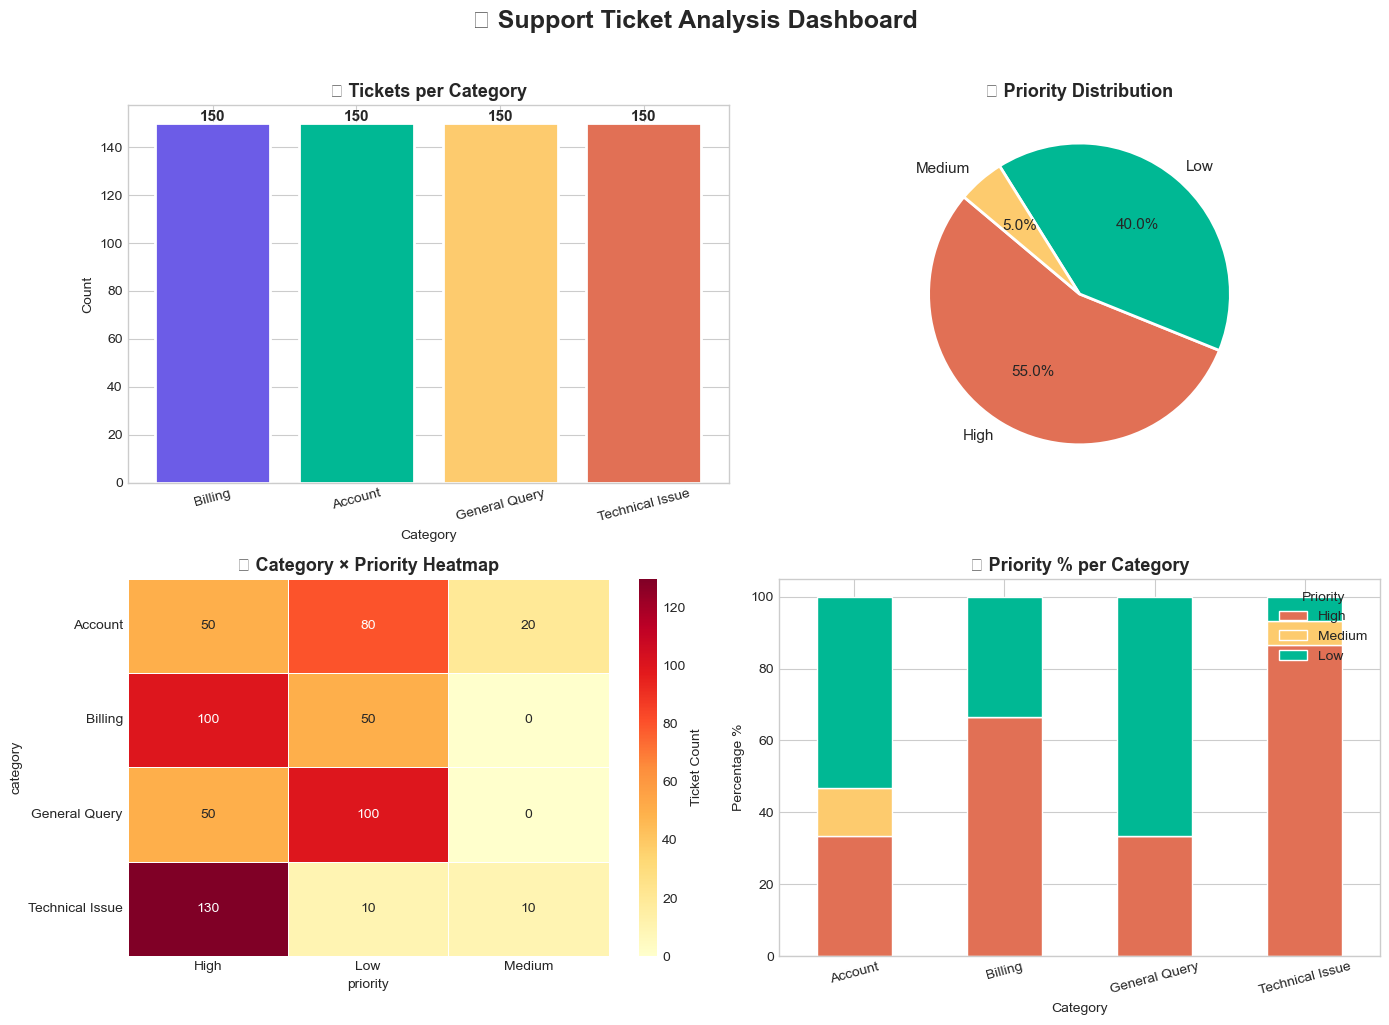

✅ Saare graphs ban gaye!


In [5]:
# ============================================================
# PART 4 - GRAPHS & VISUALIZATIONS
# ============================================================

plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ["#6C5CE7", "#00B894", "#FDCB6E", "#E17055"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("🎫 Support Ticket Analysis Dashboard", 
             fontsize=18, fontweight='bold', y=1.02)

# --- Graph 1: Category Distribution (Bar Chart) ---
cat_counts = df['category'].value_counts()
bars = axes[0,0].bar(cat_counts.index, cat_counts.values, 
                      color=PALETTE, edgecolor='white', linewidth=2)
axes[0,0].set_title("📊 Tickets per Category", fontsize=13, fontweight='bold')
axes[0,0].set_xlabel("Category")
axes[0,0].set_ylabel("Count")
axes[0,0].tick_params(axis='x', rotation=15)
for bar, v in zip(bars, cat_counts.values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, v + 1, 
                   str(v), ha='center', fontweight='bold', fontsize=11)

# --- Graph 2: Priority Distribution (Pie Chart) ---
pri_counts = df['priority'].value_counts()
pie_colors = [{"High":"#E17055","Medium":"#FDCB6E","Low":"#00B894"}.get(p) 
              for p in pri_counts.index]
axes[0,1].pie(pri_counts.values, labels=pri_counts.index, 
              colors=pie_colors, autopct='%1.1f%%', startangle=140,
              wedgeprops=dict(edgecolor='white', linewidth=2),
              textprops={'fontsize': 11})
axes[0,1].set_title("🚦 Priority Distribution", fontsize=13, fontweight='bold')

# --- Graph 3: Category x Priority Heatmap ---
cross = pd.crosstab(df['category'], df['priority'])
sns.heatmap(cross, annot=True, fmt='d', cmap='YlOrRd', 
            ax=axes[1,0], linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Ticket Count'})
axes[1,0].set_title("🔥 Category × Priority Heatmap", fontsize=13, fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=0)

# --- Graph 4: Priority per Category (Stacked Bar) ---
cross_pct = pd.crosstab(df['category'], df['priority'], normalize='index') * 100
cross_pct[['High','Medium','Low']].plot(
    kind='bar', stacked=True, ax=axes[1,1],
    color=["#E17055","#FDCB6E","#00B894"],
    edgecolor='white', linewidth=1)
axes[1,1].set_title("📈 Priority % per Category", fontsize=13, fontweight='bold')
axes[1,1].set_xlabel("Category")
axes[1,1].set_ylabel("Percentage %")
axes[1,1].tick_params(axis='x', rotation=15)
axes[1,1].legend(title="Priority", loc='upper right')

plt.tight_layout()
plt.savefig('plots/dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saare graphs ban gaye!")

In [6]:
# ============================================================
# PART 5 - TF-IDF VECTORIZATION & MODEL TRAINING
# ============================================================

# Label Encoding
le_cat = LabelEncoder()
le_pri = LabelEncoder()
df['cat_enc'] = le_cat.fit_transform(df['category'])
df['pri_enc'] = le_pri.fit_transform(df['priority'])

# Train Test Split
X_train, X_test, yc_train, yc_test, yp_train, yp_test = train_test_split(
    df['cleaned_text'], df['cat_enc'], df['pri_enc'],
    test_size=0.2, random_state=42, stratify=df['cat_enc'])

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=1)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec  = tfidf.transform(X_test)

print("✅ TF-IDF ready!")
print(f"📊 Train size : {X_train_vec.shape}")
print(f"📊 Test size  : {X_test_vec.shape}")
print(f"\n🏷️  Categories : {list(le_cat.classes_)}")
print(f"🚦 Priorities  : {list(le_pri.classes_)}")

# Define Models
MODELS = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    "Random Forest"       : RandomForestClassifier(n_estimators=200, random_state=42),
    "LinearSVC"           : LinearSVC(max_iter=2000, random_state=42),
    "Naive Bayes"         : MultinomialNB(alpha=0.5),
}

# Train Category Models
print("\n" + "="*55)
print("🏷️  CATEGORY CLASSIFICATION")
print("="*55)

cat_results = {}
for name, clf in MODELS.items():
    clf.fit(X_train_vec, yc_train)
    preds = clf.predict(X_test_vec)
    acc = accuracy_score(yc_test, preds)
    cat_results[name] = (acc, clf, preds)
    print(f"\n  ✅ {name}: {acc*100:.2f}%")

# Train Priority Models
print("\n" + "="*55)
print("🚦 PRIORITY PREDICTION")
print("="*55)

pri_results = {}
MODELS2 = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    "Random Forest"       : RandomForestClassifier(n_estimators=200, random_state=42),
    "LinearSVC"           : LinearSVC(max_iter=2000, random_state=42),
    "Naive Bayes"         : MultinomialNB(alpha=0.5),
}
for name, clf in MODELS2.items():
    clf.fit(X_train_vec, yp_train)
    preds = clf.predict(X_test_vec)
    acc = accuracy_score(yp_test, preds)
    pri_results[name] = (acc, clf, preds)
    print(f"\n  ✅ {name}: {acc*100:.2f}%")

best_cat = max(cat_results, key=lambda n: cat_results[n][0])
best_pri = max(pri_results, key=lambda n: pri_results[n][0])

print(f"\n🏆 Best Category Model : {best_cat} ({cat_results[best_cat][0]*100:.2f}%)")
print(f"🏆 Best Priority Model : {best_pri} ({pri_results[best_pri][0]*100:.2f}%)")

✅ TF-IDF ready!
📊 Train size : (480, 379)
📊 Test size  : (120, 379)

🏷️  Categories : ['Account', 'Billing', 'General Query', 'Technical Issue']
🚦 Priorities  : ['High', 'Low', 'Medium']

🏷️  CATEGORY CLASSIFICATION

  ✅ Logistic Regression: 100.00%

  ✅ Random Forest: 100.00%

  ✅ LinearSVC: 100.00%

  ✅ Naive Bayes: 100.00%

🚦 PRIORITY PREDICTION

  ✅ Logistic Regression: 100.00%

  ✅ Random Forest: 100.00%

  ✅ LinearSVC: 100.00%

  ✅ Naive Bayes: 78.33%

🏆 Best Category Model : Logistic Regression (100.00%)
🏆 Best Priority Model : Logistic Regression (100.00%)


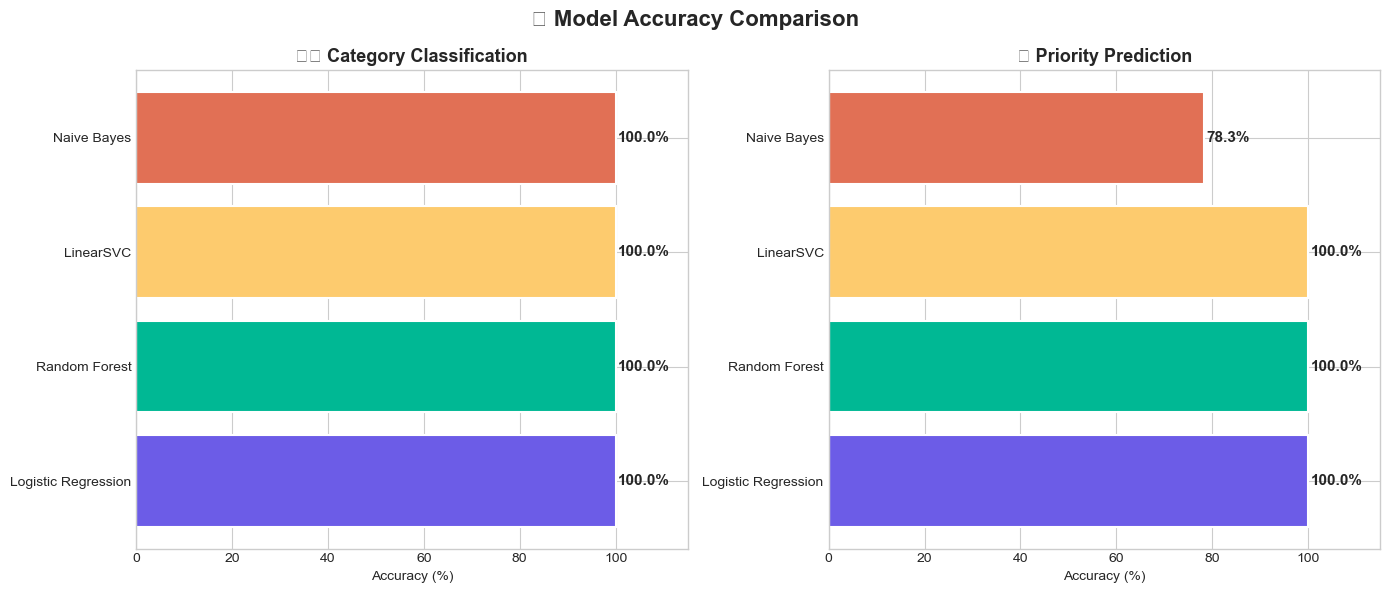

✅ Model comparison graph ban gaya!


In [7]:
# ============================================================
# PART 6 - MODEL ACCURACY COMPARISON GRAPH
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("🏆 Model Accuracy Comparison", fontsize=16, fontweight='bold')

PALETTE = ["#6C5CE7", "#00B894", "#FDCB6E", "#E17055"]
names = list(cat_results.keys())

# --- Graph 1: Category Accuracy ---
cat_accs = [cat_results[n][0]*100 for n in names]
bars1 = axes[0].barh(names, cat_accs, color=PALETTE, edgecolor='white', linewidth=1.5)
axes[0].set_title("🏷️ Category Classification", fontweight='bold', fontsize=13)
axes[0].set_xlabel("Accuracy (%)")
axes[0].set_xlim(0, 115)
for bar, v in zip(bars1, cat_accs):
    axes[0].text(v + 0.5, bar.get_y() + bar.get_height()/2,
                 f"{v:.1f}%", va='center', fontweight='bold', fontsize=11)

# --- Graph 2: Priority Accuracy ---
pri_accs = [pri_results[n][0]*100 for n in names]
bars2 = axes[1].barh(names, pri_accs, color=PALETTE, edgecolor='white', linewidth=1.5)
axes[1].set_title("🚦 Priority Prediction", fontweight='bold', fontsize=13)
axes[1].set_xlabel("Accuracy (%)")
axes[1].set_xlim(0, 115)
for bar, v in zip(bars2, pri_accs):
    axes[1].text(v + 0.5, bar.get_y() + bar.get_height()/2,
                 f"{v:.1f}%", va='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('plots/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Model comparison graph ban gaya!")

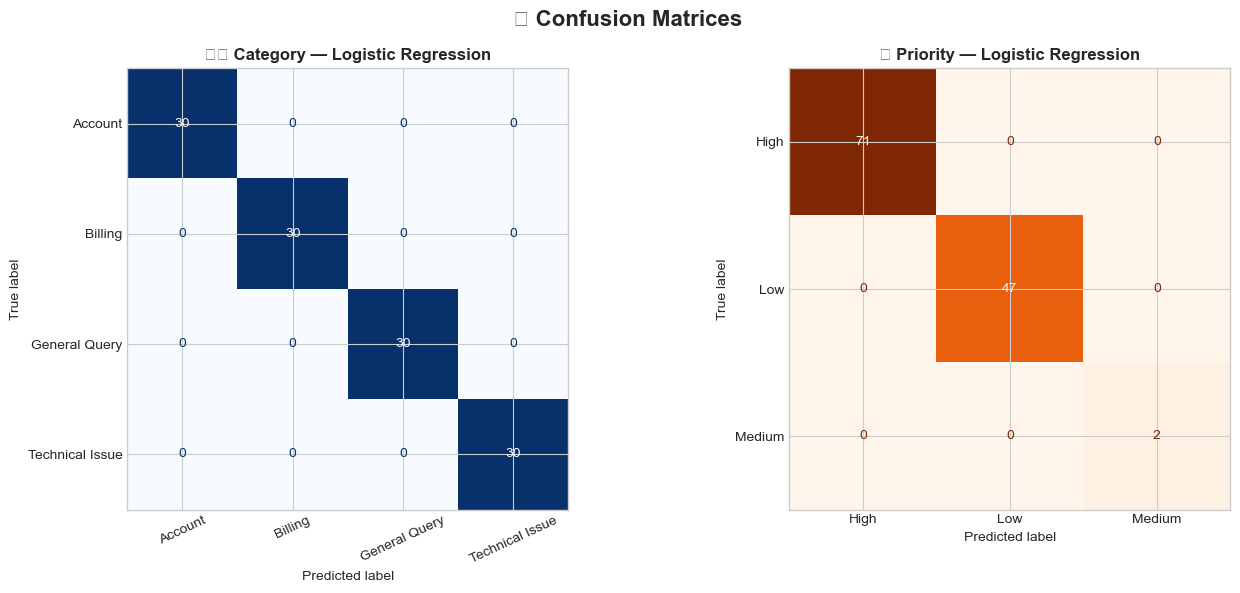

✅ Confusion matrices ban gayi!


In [8]:
# ============================================================
# PART 7 - CONFUSION MATRIX
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("🔍 Confusion Matrices", fontsize=16, fontweight='bold')

# --- Category Confusion Matrix ---
best_cat_clf = cat_results[best_cat][1]
cm_cat = confusion_matrix(yc_test, best_cat_clf.predict(X_test_vec),
                          labels=sorted(set(yc_test)))
cat_labels = [le_cat.classes_[i] for i in sorted(set(yc_test))]
disp1 = ConfusionMatrixDisplay(cm_cat, display_labels=cat_labels)
disp1.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f"🏷️ Category — {best_cat}", fontweight='bold', fontsize=12)
axes[0].tick_params(axis='x', rotation=25)

# --- Priority Confusion Matrix ---
best_pri_clf = pri_results[best_pri][1]
cm_pri = confusion_matrix(yp_test, best_pri_clf.predict(X_test_vec),
                          labels=sorted(set(yp_test)))
pri_labels = [le_pri.classes_[i] for i in sorted(set(yp_test))]
disp2 = ConfusionMatrixDisplay(cm_pri, display_labels=pri_labels)
disp2.plot(ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title(f"🚦 Priority — {best_pri}", fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('plots/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrices ban gayi!")

📋 CATEGORY - DETAILED CLASSIFICATION REPORT
                 precision    recall  f1-score   support

        Account       1.00      1.00      1.00        30
        Billing       1.00      1.00      1.00        30
  General Query       1.00      1.00      1.00        30
Technical Issue       1.00      1.00      1.00        30

       accuracy                           1.00       120
      macro avg       1.00      1.00      1.00       120
   weighted avg       1.00      1.00      1.00       120

📋 PRIORITY - DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        71
         Low       1.00      1.00      1.00        47
      Medium       1.00      1.00      1.00         2

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



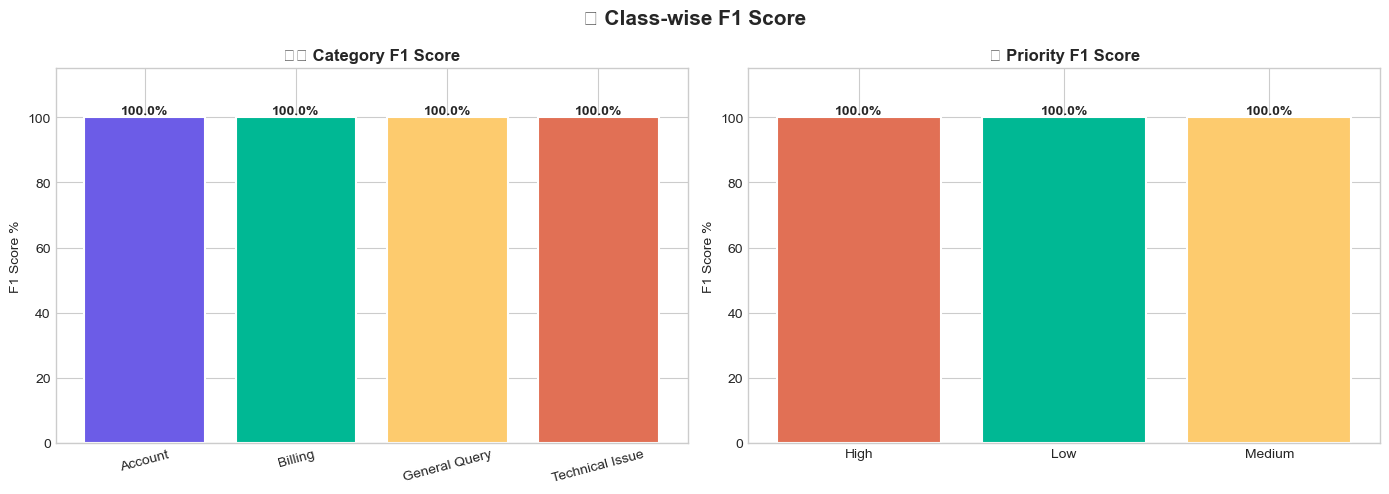

✅ Classification report aur F1 graphs ban gaye!


In [9]:
# ============================================================
# PART 8 - DETAILED CLASSIFICATION REPORT
# ============================================================

print("="*60)
print("📋 CATEGORY - DETAILED CLASSIFICATION REPORT")
print("="*60)
present_cat = sorted(set(yc_test))
cat_names   = [le_cat.classes_[i] for i in present_cat]
print(classification_report(
    yc_test, best_cat_clf.predict(X_test_vec),
    labels=present_cat, target_names=cat_names, zero_division=0))

print("="*60)
print("📋 PRIORITY - DETAILED CLASSIFICATION REPORT")
print("="*60)
present_pri = sorted(set(yp_test))
pri_names   = [le_pri.classes_[i] for i in present_pri]
print(classification_report(
    yp_test, best_pri_clf.predict(X_test_vec),
    labels=present_pri, target_names=pri_names, zero_division=0))

# --- Class wise performance bar chart ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("📊 Class-wise F1 Score", fontsize=15, fontweight='bold')

from sklearn.metrics import f1_score

# Category F1
cat_f1 = f1_score(yc_test, best_cat_clf.predict(X_test_vec),
                  average=None, labels=present_cat, zero_division=0)
axes[0].bar(cat_names, cat_f1*100, color=["#6C5CE7","#00B894","#FDCB6E","#E17055"],
            edgecolor='white', linewidth=1.5)
axes[0].set_title("🏷️ Category F1 Score", fontweight='bold')
axes[0].set_ylabel("F1 Score %")
axes[0].set_ylim(0, 115)
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(cat_f1*100):
    axes[0].text(i, v+1, f"{v:.1f}%", ha='center', fontweight='bold')

# Priority F1
pri_f1 = f1_score(yp_test, best_pri_clf.predict(X_test_vec),
                  average=None, labels=present_pri, zero_division=0)
axes[1].bar(pri_names, pri_f1*100,
            color=["#E17055","#00B894","#FDCB6E"][:len(pri_names)],
            edgecolor='white', linewidth=1.5)
axes[1].set_title("🚦 Priority F1 Score", fontweight='bold')
axes[1].set_ylabel("F1 Score %")
axes[1].set_ylim(0, 115)
for i, v in enumerate(pri_f1*100):
    axes[1].text(i, v+1, f"{v:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('plots/f1_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Classification report aur F1 graphs ban gaye!")

In [10]:
# ============================================================
# PART 9 - MODELS SAVE KARO
# ============================================================

os.makedirs("models", exist_ok=True)

joblib.dump(best_cat_clf, "models/category_model.pkl")
joblib.dump(best_pri_clf, "models/priority_model.pkl")
joblib.dump(tfidf,        "models/tfidf_vectorizer.pkl")
joblib.dump(le_cat,       "models/label_encoder_category.pkl")
joblib.dump(le_pri,       "models/label_encoder_priority.pkl")

print("✅ Saare models save ho gaye!")
print("\n📁 Saved files:")
print("   ✔ category_model.pkl")
print("   ✔ priority_model.pkl")
print("   ✔ tfidf_vectorizer.pkl")
print("   ✔ label_encoder_category.pkl")
print("   ✔ label_encoder_priority.pkl")

✅ Saare models save ho gaye!

📁 Saved files:
   ✔ category_model.pkl
   ✔ priority_model.pkl
   ✔ tfidf_vectorizer.pkl
   ✔ label_encoder_category.pkl
   ✔ label_encoder_priority.pkl


In [11]:
# ============================================================
# PART 10 - LIVE TICKET PREDICTIONS
# ============================================================

CAT_EMOJI = {"Billing":"💳", "Technical Issue":"🔧",
             "Account":"👤", "General Query":"❓"}
PRI_EMOJI = {"High":"🔴", "Medium":"🟡", "Low":"🟢"}

def predict_ticket(ticket_text):
    cleaned = clean_text(ticket_text)
    vec     = tfidf.transform([cleaned])
    cat     = le_cat.inverse_transform(best_cat_clf.predict(vec))[0]
    pri     = le_pri.inverse_transform(best_pri_clf.predict(vec))[0]
    return {
        "ticket"  : ticket_text,
        "category": f"{CAT_EMOJI.get(cat,'📋')} {cat}",
        "priority": f"{PRI_EMOJI.get(pri,'⚪')} {pri}"
    }

# Test tickets
demo_tickets = [
    "My account was charged twice ASAP I need a refund!",
    "The app crashes every time I open reports error 500",
    "How do I reset my password I forgot it completely",
    "What features are included in the premium plan",
    "I need to add a new team member to our workspace",
    "Payment failed but money was deducted from my bank",
    "My data is not syncing between devices issue",
    "Do you offer a free trial for new users signup",
]

print("="*60)
print("🎯 LIVE TICKET PREDICTIONS")
print("="*60)
for ticket in demo_tickets:
    result = predict_ticket(ticket)
    print(f"\n  🎫 Ticket   : {result['ticket']}")
    print(f"     Category : {result['category']}")
    print(f"     Priority : {result['priority']}")
    print(f"  {'─'*55}")

🎯 LIVE TICKET PREDICTIONS

  🎫 Ticket   : My account was charged twice ASAP I need a refund!
     Category : 💳 Billing
     Priority : 🔴 High
  ───────────────────────────────────────────────────────

  🎫 Ticket   : The app crashes every time I open reports error 500
     Category : 🔧 Technical Issue
     Priority : 🔴 High
  ───────────────────────────────────────────────────────

  🎫 Ticket   : How do I reset my password I forgot it completely
     Category : 🔧 Technical Issue
     Priority : 🔴 High
  ───────────────────────────────────────────────────────

  🎫 Ticket   : What features are included in the premium plan
     Category : ❓ General Query
     Priority : 🟢 Low
  ───────────────────────────────────────────────────────

  🎫 Ticket   : I need to add a new team member to our workspace
     Category : 👤 Account
     Priority : 🟢 Low
  ───────────────────────────────────────────────────────

  🎫 Ticket   : Payment failed but money was deducted from my bank
     Category : 💳 Billi

In [12]:
# ============================================================
# PART 11 - FINAL SUMMARY
# ============================================================

print("="*60)
print("📋 FINAL PROJECT SUMMARY")
print("="*60)
print(f"\n  📊 Total Tickets Analysed : {len(df)}")
print(f"  🏷️  Categories Found       : {list(df['category'].unique())}")
print(f"  🚦 Priority Levels        : {sorted(df['priority'].unique())}")

print(f"\n  {'─'*55}")
print(f"  MODEL PERFORMANCE:")
print(f"  {'─'*55}")
for name in cat_results:
    print(f"  {name:<25} | Cat: {cat_results[name][0]*100:.1f}%  | Pri: {pri_results[name][0]*100:.1f}%")

print(f"\n  {'─'*55}")
print(f"  🏆 Best Category Model    : {best_cat}")
print(f"  🏆 Best Category Accuracy : {cat_results[best_cat][0]*100:.2f}%")
print(f"\n  🏆 Best Priority Model    : {best_pri}")
print(f"  🏆 Best Priority Accuracy : {pri_results[best_pri][0]*100:.2f}%")

print(f"\n  {'─'*55}")
print(f"  📁 Graphs Saved:")
print(f"     ✔ plots/dashboard.png")
print(f"     ✔ plots/model_comparison.png")
print(f"     ✔ plots/confusion_matrices.png")
print(f"     ✔ plots/f1_scores.png")
print(f"\n  💾 Models Saved in /models/ folder")
print(f"\n{'='*60}")
print(f"  ✅ PROJECT COMPLETE! GITHUB PAR UPLOAD KARO! 🚀")
print(f"{'='*60}")

📋 FINAL PROJECT SUMMARY

  📊 Total Tickets Analysed : 600
  🏷️  Categories Found       : ['Billing', 'Account', 'General Query', 'Technical Issue']
  🚦 Priority Levels        : ['High', 'Low', 'Medium']

  ───────────────────────────────────────────────────────
  MODEL PERFORMANCE:
  ───────────────────────────────────────────────────────
  Logistic Regression       | Cat: 100.0%  | Pri: 100.0%
  Random Forest             | Cat: 100.0%  | Pri: 100.0%
  LinearSVC                 | Cat: 100.0%  | Pri: 100.0%
  Naive Bayes               | Cat: 100.0%  | Pri: 78.3%

  ───────────────────────────────────────────────────────
  🏆 Best Category Model    : Logistic Regression
  🏆 Best Category Accuracy : 100.00%

  🏆 Best Priority Model    : Logistic Regression
  🏆 Best Priority Accuracy : 100.00%

  ───────────────────────────────────────────────────────
  📁 Graphs Saved:
     ✔ plots/dashboard.png
     ✔ plots/model_comparison.png
     ✔ plots/confusion_matrices.png
     ✔ plots/f1_scores.png